In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Model training and preprocessing
from sklearn.model_selection import train_test_split
from sklearn .preprocessing import StandardScaler

#For metrics performance
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#ML algorithm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#Uploading the excel file
from google.colab import files
uploaded = files.upload()

Saving default of credit card clients.xls to default of credit card clients (1).xls


In [ ]:
#To list the name of the dataset
!ls

'default of credit card clients (1).xls'   sample_data
'default of credit card clients.xls'


In [ ]:
print(type(X_train))
print(type(X_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
#To read the excel file
df = pd.read_excel("default of credit card clients.xls", header=1)

In [ ]:
#Finding the datatype of the dataset

df.dtypes

,0
ID,int64
LIMIT_BAL,int64
SEX,int64
EDUCATION,int64
MARRIAGE,int64
AGE,int64
PAY_0,int64
PAY_2,int64
PAY_3,int64
PAY_4,int64


In [ ]:
#To print the first five rows of the dataset
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [ ]:
#To find the null values in the dataset and providing the sum of it
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [ ]:

df["default payment next month"].value_counts()

,count
default payment next month,
0,23364
1,6636


In [ ]:

df["default payment next month"].value_counts(normalize=True)

,proportion
default payment next month,
0,0.7788
1,0.2212


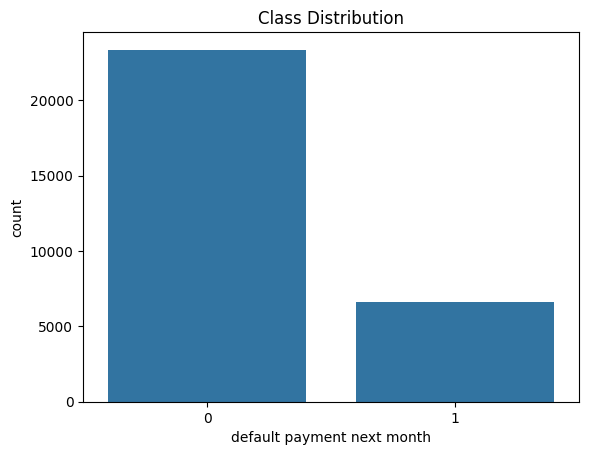

In [ ]:

sns.countplot(x="default payment next month", data=df)
plt.title("Class Distribution")
plt.show()

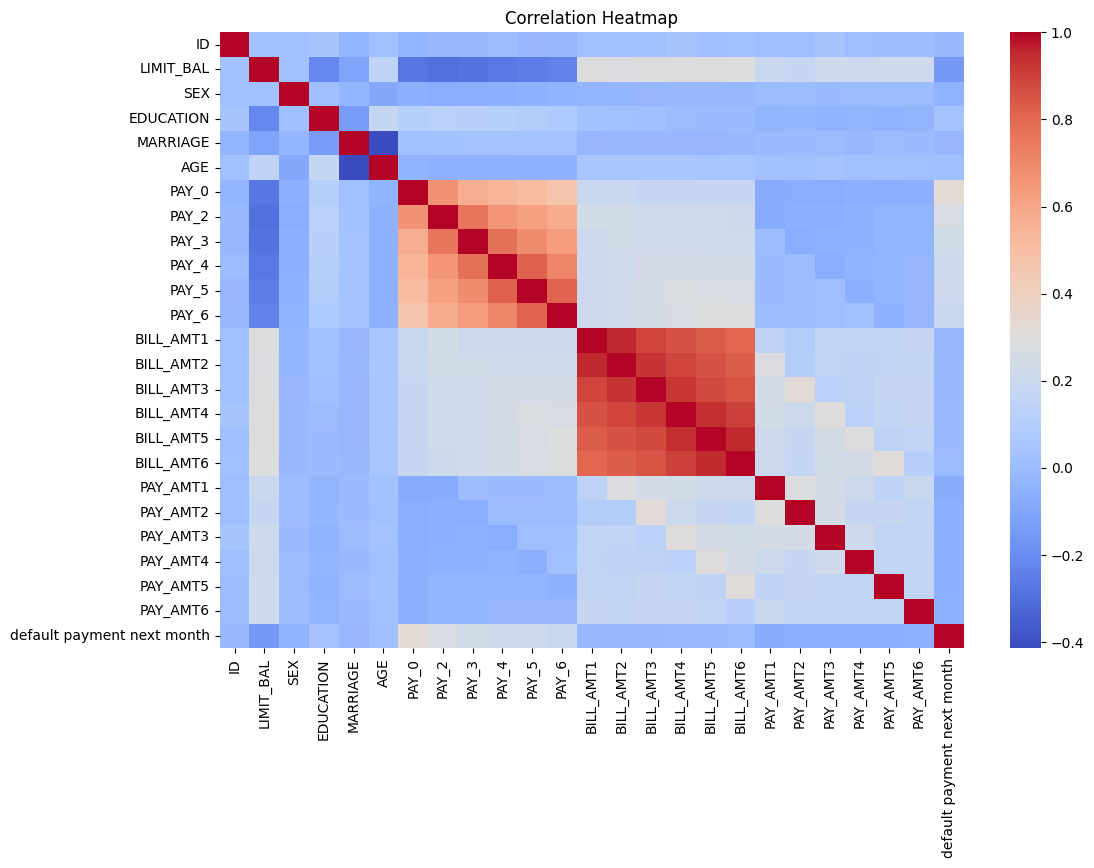

In [ ]:
#Correlation heatmap with exact figure size with the help of seaborn library
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

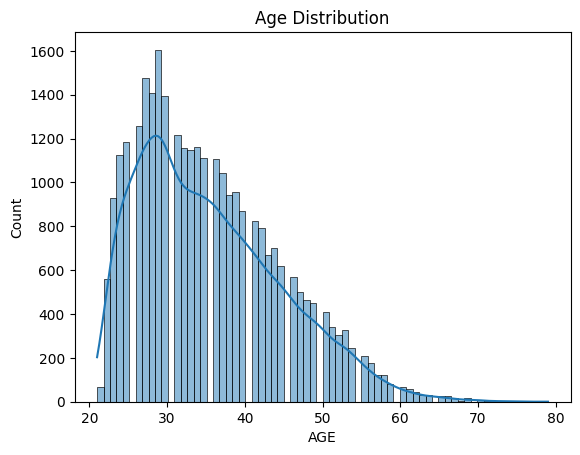

In [ ]:
# with the help of a visualization tool like histogram plot
sns.histplot(df["AGE"], kde=True)
plt.title("Age Distribution")
plt.show()

In [ ]:
X = df.drop("default payment next month", axis=1)
y = df["default payment next month"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

In [ ]:
y_train_smote.value_counts()

,count
default payment next month,
0,18691
1,18691


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

In [ ]:
!pip install xgboost

In [ ]:
results = []

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr = LogisticRegression(penalty='l2', class_weight='balanced', max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:,1]

results.append([
    "Logistic Regression",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc_score(y_test, y_prob)
])

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_prob = knn.predict_proba(X_test_scaled)[:,1]

results.append([
    "KNN",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc_score(y_test, y_prob)
])

In [ ]:
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]

results.append([
    "Decision Tree",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc_score(y_test, y_prob)
])

In [ ]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

results.append([
    "Random Forest",
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc_score(y_test, y_prob)
])

In [ ]:
# Reduce training size for heavy models
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]

X_train_scaled_small = X_train_scaled[:10000]

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel='linear', probability=True, class_weight='balanced')

svm.fit(X_train_scaled_small, y_train_small)

y_pred = svm.predict(X_test_scaled)
y_prob = svm.predict_proba(X_test_scaled)[:,1]

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, max_depth=3)

gb.fit(X_train_small, y_train_small)

y_pred = gb.predict(X_test)
y_prob = gb.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, max_depth=3)

gb.fit(X_train_small, y_train_small)

y_pred = gb.predict(X_test)
y_prob = gb.predict_proba(X_test)[:,1]

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb.fit(X_train_small, y_train_small)

y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:19:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
comparison = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"
])

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.679667,0.367247,0.620196,0.461323,0.708115
1,KNN,0.792833,0.548724,0.356443,0.432161,0.701435
2,Decision Tree,0.730500,0.388974,0.382818,0.385872,0.605832
3,Random Forest,0.813333,0.647226,0.342879,0.448276,0.752155
4,Random Forest,0.813333,0.647226,0.342879,0.448276,0.752155
5,SVM,0.776333,0.494997,0.559156,0.525124,0.753834
6,Naive Bayes,0.752500,0.451474,0.553881,0.497462,0.724930
7,Naive Bayes,0.752500,0.451474,0.553881,0.497462,0.724930
8,Gradient Boosting,0.818333,0.663448,0.362472,0.468811,0.778435


In [ ]:
#tune random forest simple grid search

from sklearn.model_selection import GridSearchCV

# Define model
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

# Small parameter grid (safe & fast)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
}

# Grid Search
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10], 'n_estimators': [100, 200]},
             scoring='roc_auc')

In [ ]:
grid_rf.best_params_

{'max_depth': 10, 'n_estimators': 200}

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score

best_rf = grid_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print("Tuned RF ROC-AUC:", roc_auc_score(y_test, y_prob_rf_tuned))

Tuned RF Accuracy: 0.7896666666666666
Tuned RF ROC-AUC: 0.7747830979519506


In [ ]:
# tune XGBoost
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'max_depth': [3, 5], 'n_estimators': [100, 200]},
             scoring='roc_auc')

In [ ]:
grid_xgb.best_params_

{'max_depth': 3, 'n_estimators': 100}

In [ ]:
best_xgb = grid_xgb.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned XGB Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("Tuned XGB ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_tuned))

Tuned XGB Accuracy: 0.817
Tuned XGB ROC-AUC: 0.7779029622463602


In [ ]:
# Baseline Random Forest
rf_baseline = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_baseline.fit(X_train, y_train)

y_prob_rf_baseline = rf_baseline.predict_proba(X_test)[:,1]
roc_rf_baseline = roc_auc_score(y_test, y_prob_rf_baseline)


#Tuned Random Forest
best_rf = grid_rf.best_estimator_

y_prob_rf_tuned = best_rf.predict_proba(X_test)[:,1]
roc_rf_tuned = roc_auc_score(y_test, y_prob_rf_tuned)


#Baseline XGBoost
xgb_baseline = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_baseline.fit(X_train, y_train)

y_prob_xgb_baseline = xgb_baseline.predict_proba(X_test)[:,1]
roc_xgb_baseline = roc_auc_score(y_test, y_prob_xgb_baseline)


#Tuned XGBoost
best_xgb = grid_xgb.best_estimator_

y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:,1]
roc_xgb_tuned = roc_auc_score(y_test, y_prob_xgb_tuned)


# Comparison Table
tuning_results = pd.DataFrame({
    "Model": ["RF Baseline", "RF Tuned",
              "XGB Baseline", "XGB Tuned"],
    "ROC-AUC": [roc_rf_baseline, roc_rf_tuned,
                roc_xgb_baseline, roc_xgb_tuned]
})

tuning_results

,Model,ROC-AUC
0,RF Baseline,0.763288
1,RF Tuned,0.774783
2,XGB Baseline,0.759020
3,XGB Tuned,0.777903


In [ ]:
# Train ROC-AUC
y_train_prob = best_rf.predict_proba(X_train)[:,1]
train_roc = roc_auc_score(y_train, y_train_prob)

# Test ROC-AUC
y_test_prob = best_rf.predict_proba(X_test)[:,1]
test_roc = roc_auc_score(y_test, y_test_prob)

print("Train ROC-AUC:", train_roc)
print("Test ROC-AUC:", test_roc)

Train ROC-AUC: 0.8705192099216976
Test ROC-AUC: 0.7747830979519506


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_rf, X_train, y_train,
                            cv=5, scoring='roc_auc')

print("Cross-validation ROC-AUC scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

Cross-validation ROC-AUC scores: [0.77625477 0.78670477 0.7709625  0.78382021 0.77562903]
Mean CV Score: 0.7786742577640292


In [ ]:
best_model_name = tuning_results.loc[tuning_results["ROC-AUC"].idxmax(), "Model"]
best_score = tuning_results["ROC-AUC"].max()

print("Best Model:", best_model_name)
print("Best ROC-AUC:", best_score)

Best Model: XGB Tuned
Best ROC-AUC: 0.7779029622463602
